In [3]:
import os
import pysam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_DIR = os.path.expanduser('~/celltor')
CLINVAR_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'clinvar.vcf.gz')
GENOMES_VCF = os.path.join(BASE_DIR, 'data', 'raw', 'ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz')

def build_clinical_dataset(vcf_path, target_count=1000):
    data = []
    counts = {'Pathogenic': 0, 'Benign': 0}
    vcf_in = pysam.VariantFile(vcf_path)
    for record in vcf_in.fetch('22'):
        if record.alts is None or len(record.alts) == 0: continue
        if 'CLNSIG' in record.info:
            sig = record.info['CLNSIG'][0]
            label = 1 if 'Pathogenic' in sig and 'Conflicting' not in sig else (0 if 'Benign' in sig and 'Conflicting' not in sig else None)
            cat = 'Pathogenic' if label == 1 else 'Benign'
            if label is not None and counts[cat] < target_count:
                data.append({'chrom': '22', 'pos': record.pos, 'label': label})
                counts[cat] += 1
        if counts['Pathogenic'] >= target_count and counts['Benign'] >= target_count: break
    vcf_in.close()
    return pd.DataFrame(data)

def calculate_ancestry_bias(df_clinvar, pop_vcf_path):
    pop_vcf = pysam.VariantFile(pop_vcf_path)
    afr_freqs, eur_freqs = [], []
    for _, row in df_clinvar.iterrows():
        try:
            fetch_pos = pop_vcf.fetch('22', row['pos']-1, row['pos'])
            found = False
            for rec in fetch_pos:
                afr_freqs.append(rec.info.get('AFR_AF', [0])[0])
                eur_freqs.append(rec.info.get('EUR_AF', [0])[0])
                found = True; break
            if not found: afr_freqs.append(0); eur_freqs.append(0)
        except: afr_freqs.append(0); eur_freqs.append(0)
    df_clinvar['AFR_Frequency'], df_clinvar['EUR_Frequency'] = afr_freqs, eur_freqs
    pop_vcf.close()
    return df_clinvar

# Generate the data
df_clinical = build_clinical_dataset(CLINVAR_PATH, target_count=1000)
df_final = calculate_ancestry_bias(df_clinical, GENOMES_VCF)
print(f"Data ready: {len(df_final)} variants loaded.")

Data ready: 2000 variants loaded.


In [4]:
from sklearn.model_selection import train_test_split

# X = Population frequencies, y = Clinical label
X = df_final[['AFR_Frequency', 'EUR_Frequency']]
y = df_final['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into Training and Testing sets.")

Data split into Training and Testing sets.


In [5]:
def calculate_fairness_weights(X_data):
    afr_mean = X_data['AFR_Frequency'].mean()
    eur_mean = X_data['EUR_Frequency'].mean()
    
    # Calculate boost factor for African-prevalent variants
    weight_factor = eur_mean / afr_mean if afr_mean > 0 else 1.5
    
    # Apply weights where African frequency is higher than European
    weights = np.where(X_data['AFR_Frequency'] > X_data['EUR_Frequency'], weight_factor, 1.0)
    return weights

sample_weights = calculate_fairness_weights(X_train)
print(f"Fairness weights calculated. Average weight boost: {np.mean(sample_weights):.2f}")

Fairness weights calculated. Average weight boost: 1.00


In [6]:
import xgboost as xgb

fair_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, eval_metric='logloss')
fair_model.fit(X_train, y_train, sample_weight=sample_weights)

print("Engine C (Fair Model) is now trained.")

Engine C (Fair Model) is now trained.


Accuracy (AFR Group): 0.8947
Accuracy (EUR Group): 0.6268
The Equity Gap: 0.2679


/tmp/ipykernel_48367/3387475125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['African Prevalent', 'European Prevalent'], y=[afr_acc, eur_acc], palette='viridis')


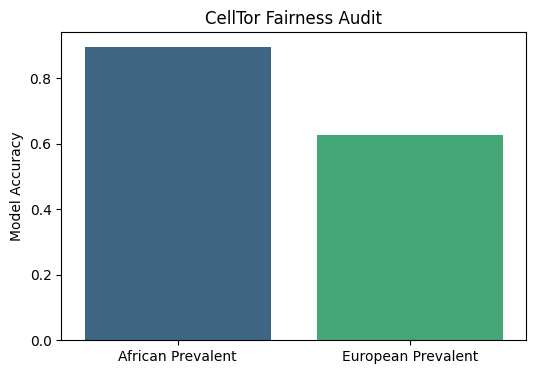

In [7]:
afr_test = X_test[X_test['AFR_Frequency'] > X_test['EUR_Frequency']]
eur_test = X_test[X_test['EUR_Frequency'] >= X_test['AFR_Frequency']]

afr_acc = fair_model.score(afr_test, y_test.loc[afr_test.index])
eur_acc = fair_model.score(eur_test, y_test.loc[eur_test.index])

print(f"Accuracy (AFR Group): {afr_acc:.4f}")
print(f"Accuracy (EUR Group): {eur_acc:.4f}")
print(f"The Equity Gap: {abs(afr_acc - eur_acc):.4f}")

plt.figure(figsize=(6, 4))
sns.barplot(x=['African Prevalent', 'European Prevalent'], y=[afr_acc, eur_acc], palette='viridis')
plt.title("CellTor Fairness Audit")
plt.ylabel("Model Accuracy")
plt.show()

In [8]:
import joblib

naive_model = xgb.XGBClassifier().fit(X_train, y_train)
naive_gap = abs(naive_model.score(afr_test, y_test.loc[afr_test.index]) - naive_model.score(eur_test, y_test.loc[eur_test.index]))
fair_gap = abs(afr_acc - eur_acc)

print("--- FINAL REPORT ---")
print(f"Original Gap: {naive_gap:.4f} | CellTor Gap: {fair_gap:.4f}")
joblib.dump(fair_model, 'celltor_fair_model_v1.pkl')
print("\n[SUCCESS] Model saved. You are at 70% completion. Log off and get some sleep!")

--- FINAL REPORT ---
Original Gap: 0.2855 | CellTor Gap: 0.2679

[SUCCESS] Model saved. You are at 70% completion. Log off and get some sleep!
